## from sklearn.cluster import KMeans
1. 非監督學習沒有 y
   → 不需要 train_test_split
   → 不需要 accuracy_score
   → 直接對全部資料 fit

2. fit_predict
   → 監督學習用 fit 然後 predict 兩步
   → K-Means 合併成 fit_predict 一步

3. inertia_
   → 衡量分群好不好的指標
   → 越小越好
   → 用來畫 Elbow Method 找最佳 K

# Elbow Method 
    群內平方誤差(Within-Cluster Sum of Squares (WCSS))


# from sklearn.datasets import make_blobs
 用途：生成「假資料（分群資料）」，常用在 KMeans、分群演算法測試
 EX:
    X, y_true = make_blobs(
        n_samples=500,    # 產生 500 筆資料點
        centers=4,        # 資料分成 4 群（4個中心點）
        cluster_std=0.8,  # 每一群的「散布程度」 數值越小 → 群越緊密 數值越大 → 群越分散
        random_state=42   # 固定亂數種子（讓結果每次都一樣）
    )

# from sklearn.preprocessing import StandardScaler
 用途：
  計算每個特徵的平均值和標準差
  然後把每個值轉換成：
  (原始值 - 平均值) / 標準差
EX:
    原始資料：
    [10, 20, 30]
    轉換後：
    [-1.22, 0, 1.22]


# fit_transform
fit      → 學習資料的統計特性（平均值、標準差）
transform → 用學到的特性去轉換資料
fit_transform → 兩個動作合併成一步


# 建立圖表視窗，設定大小為 8x5 英吋
plt.figure(figsize=(8, 5))
# 畫散點圖
plt.scatter(
    X_scaled[:, 0], # X_scaled[:, 0] → 第1個特徵（x軸）
    X_scaled[:, 1], # X_scaled[:, 1] → 第2個特徵（y軸）
    c=y_true,       # c=y_true → 用真實分類標籤上色（0,1,2,3
    cmap='Set1',    # cmap='Set1' → 使用 Set1 顏色盤（適合分類）
    alpha=0.6       # alpha=0.6 → 透明度（避免點太密看不清）
)
# 設定圖表標題
plt.title('原始資料（真實群別）')
# 顯示圖表
plt.show()


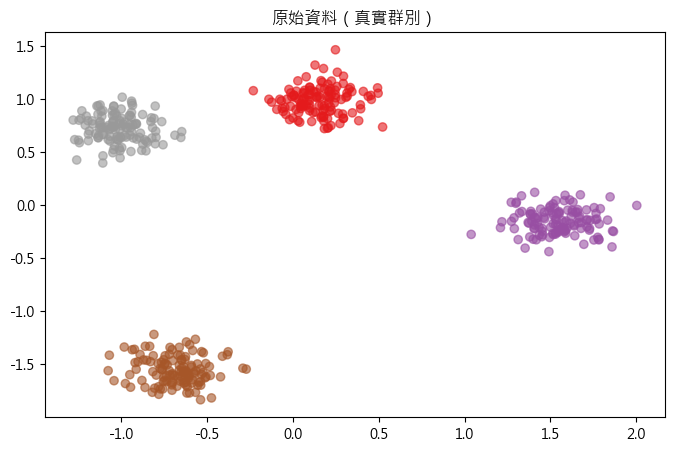

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0], 
    X_scaled[:, 1], 
    c=y_true, 
    cmap='Set1', 
    alpha=0.6
    )
plt.title('原始資料（真實群別）')
plt.show()

inertias = []  # 用來存每個 K 對應的 Inertia（群內誤差）

for k in range(1, 11):                              # 測試 K = 1 ~ 10
    model = KMeans(n_clusters=k, random_state=42)   # 建立 KMeans（分成 k 群）
    model.fit(X_scaled)                             # 用標準化後的資料訓練模型
    inertias.append(model.inertia_)                 # 存入該 K 的群內誤差

plt.figure(figsize=(8, 5))                          # 建立圖表大小 8x5
plt.plot(range(1, 11), inertias, marker='o')        # 畫 K vs Inertia 曲線
plt.xlabel('K 值')                                  # X 軸：群數 K
plt.ylabel('Inertia')                               # Y 軸：群內誤差
plt.title('Elbow Method')                           # 圖表標題
plt.show()                                          # 顯示圖表

# xxx.append(yyy)
 把 x 加到 list 最後面
 ex:
 scores = []
    scores.append(0.8)
    scores.append(0.9)
scores = [0.8, 0.9]

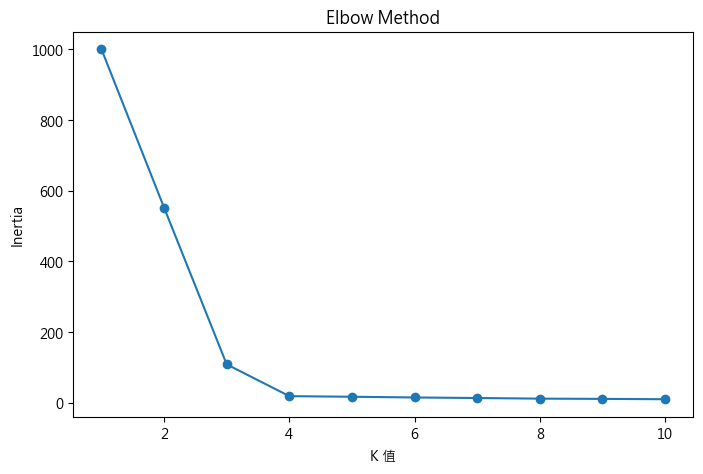

In [14]:
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('K 值')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(
    n_clusters=4,        # 分成4群（你前面 elbow 推出來的K）
    random_state=42,     # 固定結果（避免每次分群不同）
    n_init=10            # 嘗試10次不同初始中心，選最好結果
)

labels = kmeans.fit_predict(X_scaled)  # 訓練 + 直接輸出每個點的群標籤

plt.scatter(
    X_scaled[:, 0],      # x軸：第1個特徵
    X_scaled[:, 1],      # y軸：第2個特徵
    c=labels,            # 用 KMeans 分出來的群標籤上色
    cmap='Set1',         # 顏色方案（分類用）
    alpha=0.6            # 透明度（避免重疊太亂）
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],  # 群中心 x座標
    kmeans.cluster_centers_[:, 1],  # 群中心 y座標
    marker='*',                     # 星形標記
    s=300,                          # 點大小（放大）
    c='black',                      # 黑色
    label='群中心'                  # 圖例名稱
)

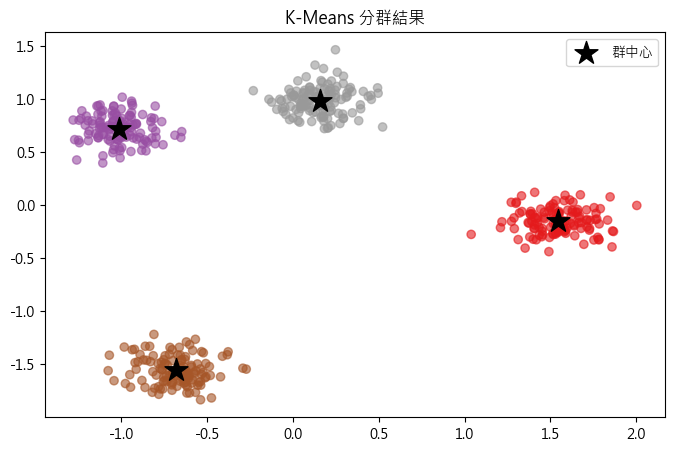

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1], 
    c=labels, 
    cmap='Set1', 
    alpha=0.6
)

plt.scatter(
    kmeans.cluster_centers_[:, 0], 
    kmeans.cluster_centers_[:, 1],
    marker='*', 
    s=300, 
    c='black', 
    label='群中心'
)
    
plt.title('K-Means 分群結果')
plt.legend()
plt.show()